# Bayesian Multinomial Logit with Pyro

In [2]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns


# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

In [3]:
df = pd.read_csv('swissmetro.dat', sep='\t')
df.to_csv('swissmetro.csv', index=False)

### Load and explore data

In [4]:
df = pd.read_csv('swissmetro.dat', sep='\t')
print(df.head())
print(df.shape)

# Filter: exclude unknown choices and non-commute/business trips
df = df[(df['CHOICE'] != 0) & ((df['PURPOSE'] == 1) | (df['PURPOSE'] == 3))]

print(f"After filtering: {df.shape[0]} rows")

# Select a random subset of 50 IDs
selected_ids = df['ID'].drop_duplicates().sample(n=50)

# Filter the dataset to include only rows with the selected IDs
df = df[df['ID'].isin(selected_ids)]

print(f"With 50 IDs: {df.shape[0]} rows")
print(f"Columns: {df.columns.tolist()}")


   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84       2  
2      52       2  
3      52       2 

In [5]:
# Check available modes and choice distribution
print(f"Unique choices: {sorted(df['CHOICE'].unique())}")
print(f"\nChoice distribution:\n{df['CHOICE'].value_counts().sort_index()}")
print(f"\nMode availability:")
print(f"TRAIN_AV: {df['TRAIN_AV'].sum()} / {len(df)}")
print(f"SM_AV: {df['SM_AV'].sum()} / {len(df)}")
print(f"CAR_AV: {df['CAR_AV'].sum()} / {len(df)}")

Unique choices: [np.int64(1), np.int64(2), np.int64(3)]

Choice distribution:
CHOICE
1     77
2    247
3    126
Name: count, dtype: int64

Mode availability:
TRAIN_AV: 450 / 450
SM_AV: 450 / 450
CAR_AV: 369 / 450


### Prepare data for choice model

Transform to long format (one row per alternative per decision) for the discrete choice model.

In [6]:
# We'll work with travel time and cost
# Modes: 1=Train, 2=SwissMetro, 3=Car

# Standardize attributes (z-score: (x - mean) / std)
df['TRAIN_TT_SCALED'] = (df['TRAIN_TT'] - df['TRAIN_TT'].mean()) / df['TRAIN_TT'].std()
df['TRAIN_CO_SCALED'] = (df['TRAIN_CO'] - df['TRAIN_CO'].mean()) / df['TRAIN_CO'].std()
df['SM_TT_SCALED'] = (df['SM_TT'] - df['SM_TT'].mean()) / df['SM_TT'].std()
df['SM_CO_SCALED'] = (df['SM_CO'] - df['SM_CO'].mean()) / df['SM_CO'].std()
df['CAR_TT_SCALED'] = (df['CAR_TT'] - df['CAR_TT'].mean()) / df['CAR_TT'].std()
df['CAR_CO_SCALED'] = (df['CAR_CO'] - df['CAR_CO'].mean()) / df['CAR_CO'].std()

print(f"Standardized data (mean≈0, std≈1):\n{df[['TRAIN_TT_SCALED', 'TRAIN_CO_SCALED', 'SM_TT_SCALED', 'SM_CO_SCALED', 'CHOICE']].head(10)}")


Standardized data (mean≈0, std≈1):
     TRAIN_TT_SCALED  TRAIN_CO_SCALED  SM_TT_SCALED  SM_CO_SCALED  CHOICE
594        -0.256379        -0.345192     -0.412461     -0.354137       2
595        -0.745722        -0.366606     -0.333378     -0.367203       2
596        -0.256379        -0.366606     -0.227934     -0.362303       2
597        -0.582608        -0.366606     -0.227934     -0.362303       2
598        -0.582608        -0.359111     -0.227934     -0.362303       2
599        -0.745722        -0.359111     -0.227934     -0.362303       2
600        -0.745722        -0.345192     -0.333378     -0.350871       1
601        -0.745722        -0.359111     -0.412461     -0.359037       2
602        -0.582608        -0.345192     -0.227934     -0.341889       2
657        -0.876214        -0.351616     -1.308733     -0.359037       2


### Convert to long format

In [ ]:
# Create long-format data for MNL estimation
# Each row observation becomes 3 rows (one per alternative that is available)

long_data = []

# Create a mapping from original indices to sequential obs_id (0, 1, 2, ...)
obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}

for idx, row in df.iterrows():
    obs_id_sequential = obs_id_map[idx]  # Map to sequential ID
    original_id = row['ID']  # Keep track of the individual ID
    
    # Train (alt_id 0)
    if row['TRAIN_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 0,
            'tt': row['TRAIN_TT_SCALED'],
            'co': row['TRAIN_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 1 else 0
        })
    
    # SwissMetro (alt_id 1)
    if row['SM_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 1,
            'tt': row['SM_TT_SCALED'],
            'co': row['SM_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 2 else 0
        })
    
    # Car (alt_id 2)
    if row['CAR_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 2,
            'tt': row['CAR_TT_SCALED'],
            'co': row['CAR_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 3 else 0
        })

long_df = pd.DataFrame(long_data)
long_df.to_csv('long_swissmetro.csv', index=False)
# Validate: exactly one choice per obs_id
choices_per_obs = long_df.groupby('obs_id')['choice'].sum()
assert (choices_per_obs == 1).all(), "Error: some observations have != 1 choice"
print("✓ Validation passed: exactly one choice per observation")
print(f"\nLong format shape: {long_df.shape}")
print(f"Number of unique observations: {long_df['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df['ID'].nunique()}")
print(f"Obs_id range: [{long_df['obs_id'].min()}, {long_df['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):")
long_df.head(9)


✓ Validation passed: exactly one choice per observation

Long format shape: (1269, 6)
Number of unique observations: 450
Number of unique individuals: 50
Obs_id range: [0, 449]

Sample (first 9 rows = 3 obs):


,obs_id,ID,alt_id,tt,co,choice
0,0,67.0,0,-0.256379,-0.345192,0
1,0,67.0,1,-0.412461,-0.354137,1
2,0,67.0,2,-0.331817,-0.305832,0
3,1,67.0,0,-0.745722,-0.366606,0
4,1,67.0,1,-0.333378,-0.367203,1
5,1,67.0,2,0.023138,-0.534983,0
6,2,67.0,0,-0.256379,-0.366606,0
7,2,67.0,1,-0.227934,-0.362303,1
8,2,67.0,2,-0.568454,-0.534983,0


In [8]:
# Convert to PyTorch tensors for Pyro
X = torch.tensor(long_df[['tt', 'co']].values, dtype=torch.float32)
Y = torch.tensor(long_df['choice'].values, dtype=torch.int64)
obs_id = torch.tensor(long_df['obs_id'].values, dtype=torch.int64)
alt_id = torch.tensor(long_df['alt_id'].values, dtype=torch.int64)

In [9]:
torch.cat((X, Y.reshape(-1, 1)), dim=1)  # Just to check shapes

tensor([[-0.2564, -0.3452,  0.0000],
        [-0.4125, -0.3541,  1.0000],
        [-0.3318, -0.3058,  0.0000],
        ...,
        [-1.0393, -0.3013,  0.0000],
        [-1.0715, -0.2864,  1.0000],
        [-0.3318, -0.3058,  0.0000]])

### Define Bayesian Multinomial Logit Model in Pyro

In [10]:
dist.MultivariateNormal(torch.zeros(2), torch.eye(2)).sample()

tensor([0.7376, 1.9459])

In [11]:
X.shape

torch.Size([1269, 2])

In [12]:
obs_id.max().item() + 1

450

In [14]:
long_df

,obs_id,ID,alt_id,tt,co,choice
0,0,67.0,0,-0.256379,-0.345192,0
1,0,67.0,1,-0.412461,-0.354137,1
2,0,67.0,2,-0.331817,-0.305832,0
3,1,67.0,0,-0.745722,-0.366606,0
4,1,67.0,1,-0.333378,-0.367203,1
...,...,...,...,...,...,...
1264,448,927.0,1,-1.071484,-0.286361,0
1265,448,927.0,2,-0.568454,0.037895,1
1266,449,927.0,0,-1.039328,-0.301293,0
1267,449,927.0,1,-1.071484,-0.286361,1


In [16]:
torch.ones(5)/5

tensor([0.2000, 0.2000, 0.2000, 0.2000, 0.2000])

In [ ]:
with pyro.plate('classes', 5):
    beta = pyro.sample('beta', dist.MultivariateNormal(torch.zeros(7), torch.eye(7)))
beta

tensor([[ 0.2479,  1.5727, -1.6395, -1.5925, -0.1546, -1.0964,  1.3666],
        [ 0.6893, -0.3935,  0.6171,  0.7528,  0.6023,  2.0175, -1.1686],
        [-1.3242,  1.1267, -0.2255,  0.5218, -2.0598, -1.5885,  0.5281],
        [ 0.8964,  0.9975, -0.2156,  0.0927,  0.3910,  1.2983,  0.0436],
        [-0.9724,  0.2803,  0.5700,  1.4841, -0.7572, -1.1598,  1.3550]])

In [25]:
K = 5
with pyro.plate('obs', 7):
    Q = pyro.sample("q", dist.Categorical(torch.ones(K)/K))
Q

tensor([2, 2, 2, 4, 0, 2, 4])

torch.Size([1269, 2]) torch.Size([1269]) tensor([  0,   0,   0,  ..., 449, 449, 449]) tensor([0, 1, 2,  ..., 0, 1, 2])
(1269,)
(1269, 2)
(1269, 2)
(1269,)
Provenance:
frozenset({'y'})
Tensor:
tensor([339, 318, 953,  ...,  72, 343, 227])


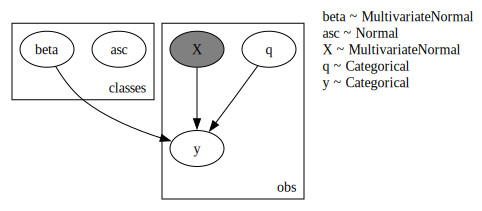

In [34]:
# WIP
def model(X_obs, Y_obs, obs_id, alt_id, n_alts=3):
    """
    Bayesian Multinomial Logit Model in Pyro
    
    Parameters:
    - X_obs: (N_alts, n_features) alternative attributes in long format
    - Y: (N_alts,) choice indicator in long format (1 if chosen, 0 otherwise)
    - obs_id: observation ID for grouping alternatives
    - alt_id: alternative ID (0, 1, 2)
    - n_alts: number of alternatives (3: Train, SwissMetro, Car)

    - V: (N_alts,) linear utility function: V_i = X_i @ beta + ASC_i
    """
    n_obs, n_features = X_obs.shape
    K = 5

    # Priors on coefficients: explicitly expand to vector
    with pyro.plate('classes', K):
        # K times n_features
        beta = pyro.sample('beta', dist.MultivariateNormal(torch.zeros(n_features), torch.eye(n_features)))
    
        # Alternative-specific constants: fix first to 0 for identification
        # Sample only for alternatives 1 and 2
        asc_zero = pyro.sample('asc', dist.Normal(0, 1))
        asc = torch.cat([torch.zeros(1, dtype=asc_zero.dtype, device=asc_zero.device), asc_zero])
    
    # Likelihood: categorical (multinomial logit)
    with pyro.plate('obs', n_obs):
        # n_obs times n_features
        X = pyro.sample('X', dist.MultivariateNormal(torch.zeros(n_features), torch.eye(n_features)), obs=X_obs)  # Add small noise to observed attributes
        # n_obs times K
        Q = pyro.sample("q", dist.Categorical(torch.ones(K)/K)) # TODO obs is needed here.
        print(Q.shape)
        # n_obs times K
        U = torch.sum(X * beta[Q, :], axis=1)
        print(X.shape)
        print(beta[Q, :].shape)
        print(U.shape)
        
        # # Convert to wide format: (n_obs, n_alts)
        # V_wide = torch.full((n_obs, n_alts), float('-inf'))
        # V_wide[obs_id, alt_id] = V
        
        # # Convert choice from long to wide format
        # Y_wide = torch.zeros(n_obs, dtype=torch.int64)
        # chosen_mask = Y == 1
        # Y_wide[obs_id[chosen_mask]] = alt_id[chosen_mask]
        y = pyro.sample('y', dist.Categorical(logits=U))
        print(y)
print(X.shape, Y.shape, obs_id, alt_id)
pyro.render_model(model, model_args=(X, Y, obs_id, alt_id), render_distributions=True)

### Run MCMC inference

In [21]:
# Use NUTS sampler for efficient HMC-based inference
nuts_kernel = NUTS(model, adapt_step_size=True)

mcmc = MCMC(nuts_kernel, num_samples=2000, warmup_steps=200, num_chains=1)

mcmc.run(X, Y, obs_id, alt_id, n_alts=3)

Sample: 100%|██████████| 2200/2200 [00:06, 342.83it/s, step size=6.07e-01, acc. prob=0.931]


### Examine results and check out plots

In [22]:
# Get posterior samples
posterior_samples = mcmc.get_samples()

print("Posterior means:")
for key, val in posterior_samples.items():
    print(f"\n{key}:")
    print(f"  Mean: {val.mean(dim=0)}")
    print(f"  Std: {val.std(dim=0)}")

Posterior means:

asc:
  Mean: tensor([1.1646, 1.0155])
  Std: tensor([0.1336, 0.1581])

beta:
  Mean: tensor([-0.6377, -0.1648])
  Std: tensor([0.1231, 0.1102])


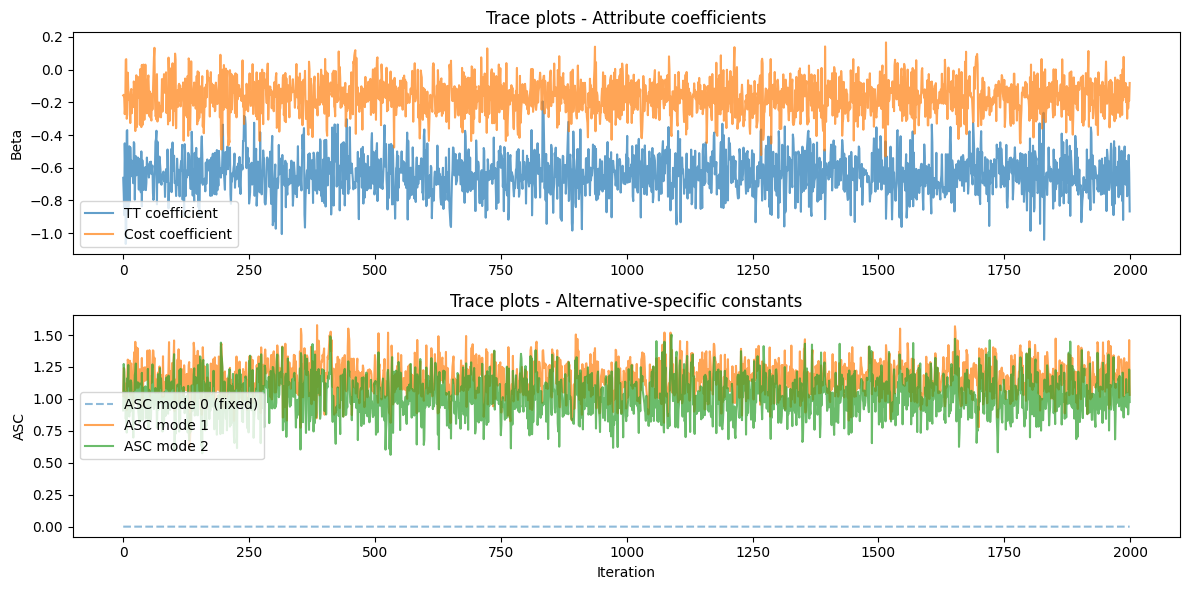

In [ ]:
# Plot trace plots for diagnostics
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Beta (attribute effects)
beta_samples = posterior_samples['beta']
axes[0].plot(beta_samples[:, 0], label='TT coefficient', alpha=0.7)
axes[0].plot(beta_samples[:, 1], label='Cost coefficient', alpha=0.7)
axes[0].set_ylabel('Beta')
axes[0].legend()
axes[0].set_title('Trace plots - Attribute coefficients')

# ASC (alternative-specific constants) - only 2 sampled (first fixed to 0)
asc_samples = posterior_samples['asc']
axes[1].plot(torch.zeros_like(asc_samples[:, 0]), label='ASC mode 0 (fixed)', alpha=0.5, linestyle='--')
for i in range(asc_samples.shape[1]):
    axes[1].plot(asc_samples[:, i], label=f'ASC mode {i+1}', alpha=0.7)
axes[1].set_ylabel('ASC')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].set_title('Trace plots - Alternative-specific constants')

plt.tight_layout()
plt.show()

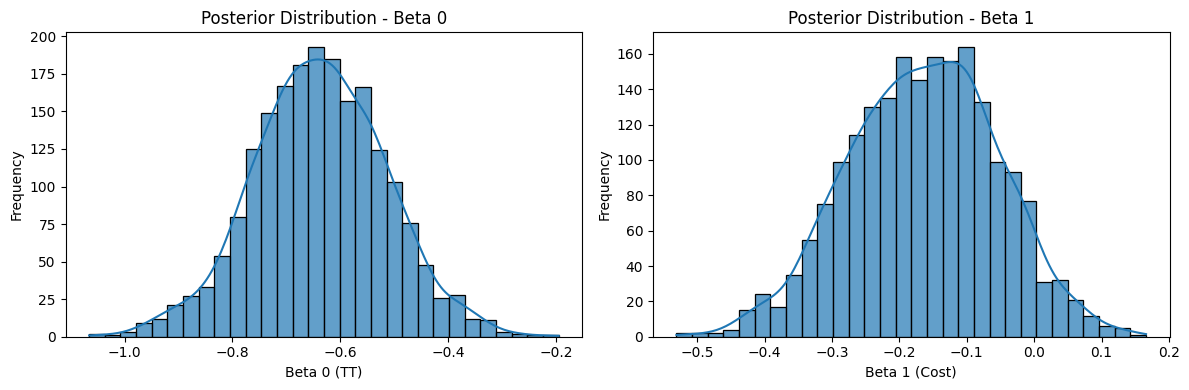

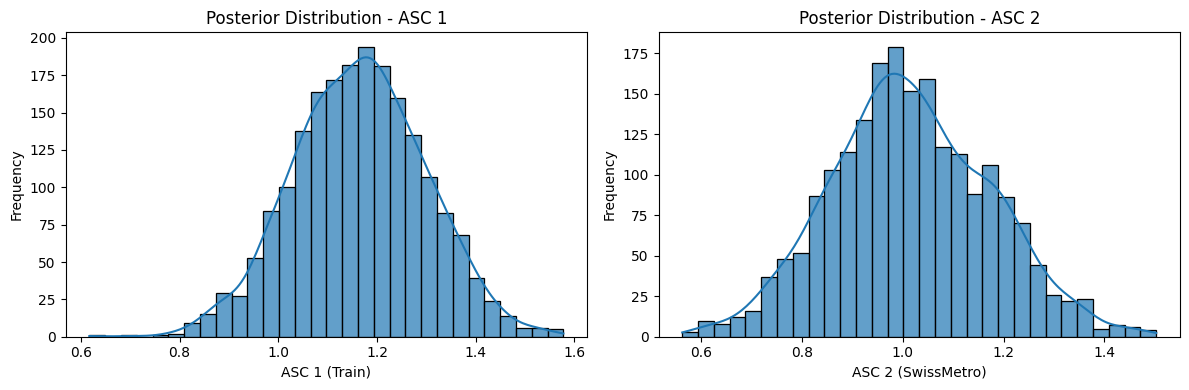

In [29]:
# Plot posterior distributions for beta (attribute coefficients)
fig, axes = plt.subplots(1, X.shape[1], figsize=(12, 4))

beta_samples = posterior_samples['beta'].detach().numpy()
for d in range(X.shape[1]):
    sns.histplot(beta_samples[:, d], bins=30, kde=True, alpha=0.7, ax=axes[d])
    axes[d].set_xlabel(f'Beta {d} ({"TT" if d==0 else "Cost"})')
    axes[d].set_ylabel('Frequency')
    axes[d].set_title(f'Posterior Distribution - Beta {d}')

plt.tight_layout()
plt.show()

# Plot posterior distributions for ASC (alternative-specific constants)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

asc_samples = posterior_samples['asc'].detach().numpy()
mode_names = ['Train', 'SwissMetro']

for c in range(asc_samples.shape[1]):
    sns.histplot(asc_samples[:, c], bins=30, kde=True, alpha=0.7, ax=axes[c])
    axes[c].set_xlabel(f'ASC {c+1} ({mode_names[c]})')
    axes[c].set_ylabel('Frequency')
    axes[c].set_title(f'Posterior Distribution - ASC {c+1}')

plt.tight_layout()
plt.show()